Read Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import cross_val_score
from scipy.stats import zscore
import graphviz

In [ ]:
df = pd.read_csv('/content/gym_members_exercise_tracking (2).csv', delimiter=';')
pd.set_option('display.expand_frame_repr', False)
print(df)
print("\nJumlah Total Data:", len(df))

print("\nStatistik Deskriptif:")
print(df.describe(include='all'))

     Age  Gender  Weight (kg)  Height (m)  Max_BPM  Avg_BPM  Resting_BPM  Session_Duration (hours)  Calories_Burned Workout_Type  Fat_Percentage  Water_Intake (liters)  Workout_Frequency (days/week)  Experience_Level    BMI
0     56    Male         88.3        1.71      180      157           60                      1.69           1313.0         Yoga            12.6                    3.5                              4                 3  30.20
1     46  Female         74.9        1.53      179      151           66                      1.30            883.0         HIIT            33.9                    2.1                              4                 2  32.00
2     32  Female         68.1        1.66      167      122           54                      1.11            677.0       Cardio            33.4                    2.3                              4                 2  24.71
3     25    Male         53.2        1.70      190      164           56                      0.59      

Cleansing Data

In [ ]:
df = df.dropna()

jumlah_data_sebelum = len(df)

df = df.drop_duplicates()

print("\nCek Nilai Hilang :")
print(df.isnull().sum())

jumlah_duplikat = jumlah_data_sebelum - len(df)
print(f"\nJumlah Data Duplikat yang Dihapus: {jumlah_duplikat}")

print(f"\nJumlah Data Sebelum Penghapusan: {jumlah_data_sebelum}")
print(f"Jumlah Data Setelah Penghapusan: {len(df)}")


Cek Nilai Hilang :
Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64

Jumlah Data Duplikat yang Dihapus: 0

Jumlah Data Sebelum Penghapusan: 973
Jumlah Data Setelah Penghapusan: 973


In [ ]:
numeric_df = df.select_dtypes(include=np.number)

z_scores = numeric_df.apply(zscore)

outliers_z = (z_scores.abs() > 3)

print(outliers_z.sum())

Age                               0
Weight (kg)                       0
Height (m)                        0
Max_BPM                           0
Avg_BPM                           0
Resting_BPM                       0
Session_Duration (hours)          0
Calories_Burned                   3
Fat_Percentage                    0
Water_Intake (liters)             0
Workout_Frequency (days/week)     0
Experience_Level                  0
BMI                              10
dtype: int64


In [ ]:
outlier_rows = df[outliers_z.any(axis=1)]
print(outlier_rows)

     Age Gender  Weight (kg)  Height (m)  Max_BPM  Avg_BPM  Resting_BPM  Session_Duration (hours)  Calories_Burned Workout_Type  Fat_Percentage  Water_Intake (liters)  Workout_Frequency (days/week)  Experience_Level    BMI
133   21   Male        125.2        1.66      196      159           60                      1.38           1207.0         HIIT            29.8                    3.4                              3                 2  45.43
251   33   Male        117.0        1.61      166      130           55                      1.04            744.0         HIIT            25.1                    2.4                              3                 2  45.14
261   57   Male        126.8        1.63      161      133           73                      0.96            632.0         Yoga            20.8                    2.1                              2                 1  47.72
291   55   Male        128.4        1.68      178      165           52                      1.13           

In [ ]:
non_outlier_index = ~outliers_z.any(axis=1)

df_cleaned = df[non_outlier_index]

print("Ukuran data setelah menghapus outlier :", df_cleaned.shape)

Ukuran data setelah menghapus outlier : (960, 15)


In [ ]:
label_encoder = LabelEncoder()

categorical_columns = ['Gender', 'Workout_Type']
for col in categorical_columns:
    df_cleaned.loc[:, col] = label_encoder.fit_transform(df_cleaned[col])

df_cleaned.head(5)

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,1,88.3,1.71,180,157,60,1.69,1313.0,3,12.6,3.5,4,3,30.20
1,46,0,74.9,1.53,179,151,66,1.30,883.0,1,33.9,2.1,4,2,32.00
2,32,0,68.1,1.66,167,122,54,1.11,677.0,0,33.4,2.3,4,2,24.71
3,25,1,53.2,1.70,190,164,56,0.59,532.0,2,28.8,2.1,3,1,18.41
4,38,1,46.1,1.79,188,158,68,0.64,556.0,2,29.2,2.8,3,1,14.39


In [ ]:
df_cleaned.to_csv('data_bersih.csv', index=False)

In [ ]:
df = pd.read_csv('/content/data_bersih.csv', delimiter=',')
print("\nJumlah Total Data:", len(df))


Jumlah Total Data: 960


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 960 entries, 0 to 959
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            960 non-null    int64  
 1   Gender                         960 non-null    int64  
 2   Weight (kg)                    960 non-null    float64
 3   Height (m)                     960 non-null    float64
 4   Max_BPM                        960 non-null    int64  
 5   Avg_BPM                        960 non-null    int64  
 6   Resting_BPM                    960 non-null    int64  
 7   Session_Duration (hours)       960 non-null    float64
 8   Calories_Burned                960 non-null    float64
 9   Workout_Type                   960 non-null    int64  
 10  Fat_Percentage                 960 non-null    float64
 11  Water_Intake (liters)          960 non-null    float64
 12  Workout_Frequency (days/week)  960 non-null    int

Split Data

In [ ]:
X = df.drop(columns=['Experience_Level'])
y = df['Experience_Level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"80% Data: {len(X_train)} samples")

print(f"20% Data: {len(X_test)} samples")

80% Data: 768 samples
20% Data: 192 samples


Modeling

Data Training

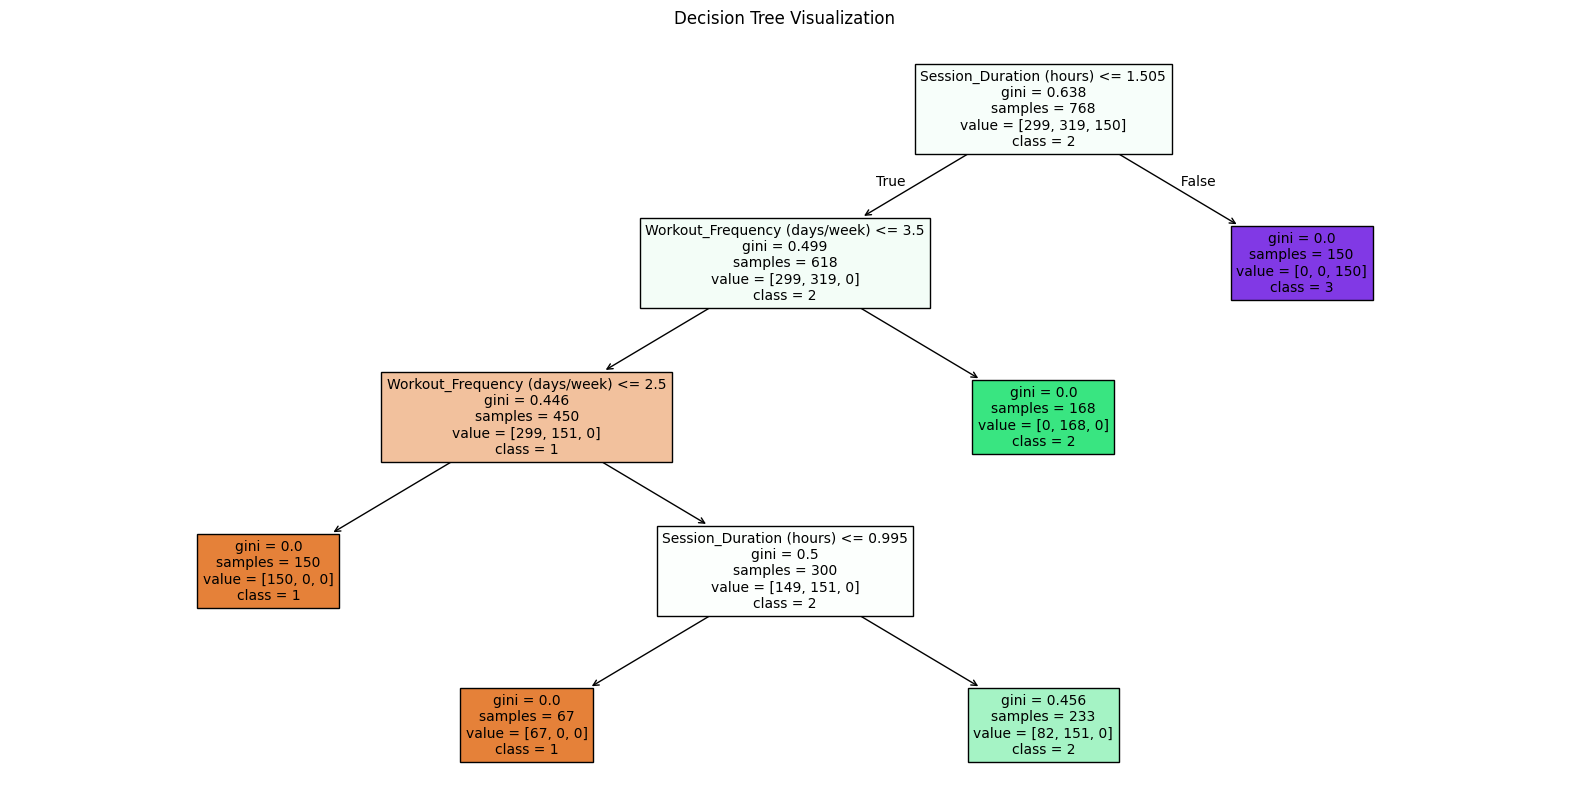

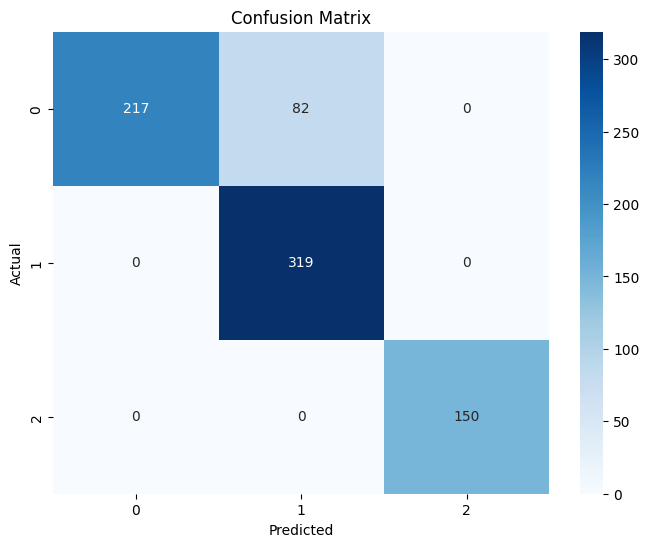


Classification Report:
              precision    recall  f1-score   support

           1       1.00      0.73      0.84       299
           2       0.80      1.00      0.89       319
           3       1.00      1.00      1.00       150

    accuracy                           0.89       768
   macro avg       0.93      0.91      0.91       768
weighted avg       0.92      0.89      0.89       768

Accuracy: 0.89


In [ ]:
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)

plt.figure(figsize=(20, 10))
plot_tree(
    model,
    feature_names=X.columns.tolist(),
    class_names=[str(c) for c in model.classes_],
    filled=True,
    fontsize=10
)
plt.title('Decision Tree Visualization')
plt.show()

conf_matrix_train = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_train, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:")
print(classification_report(y_train, y_train_pred))
accuracy = accuracy_score(y_train, y_train_pred)
print(f"Accuracy: {accuracy:.2f}")

Data Testing

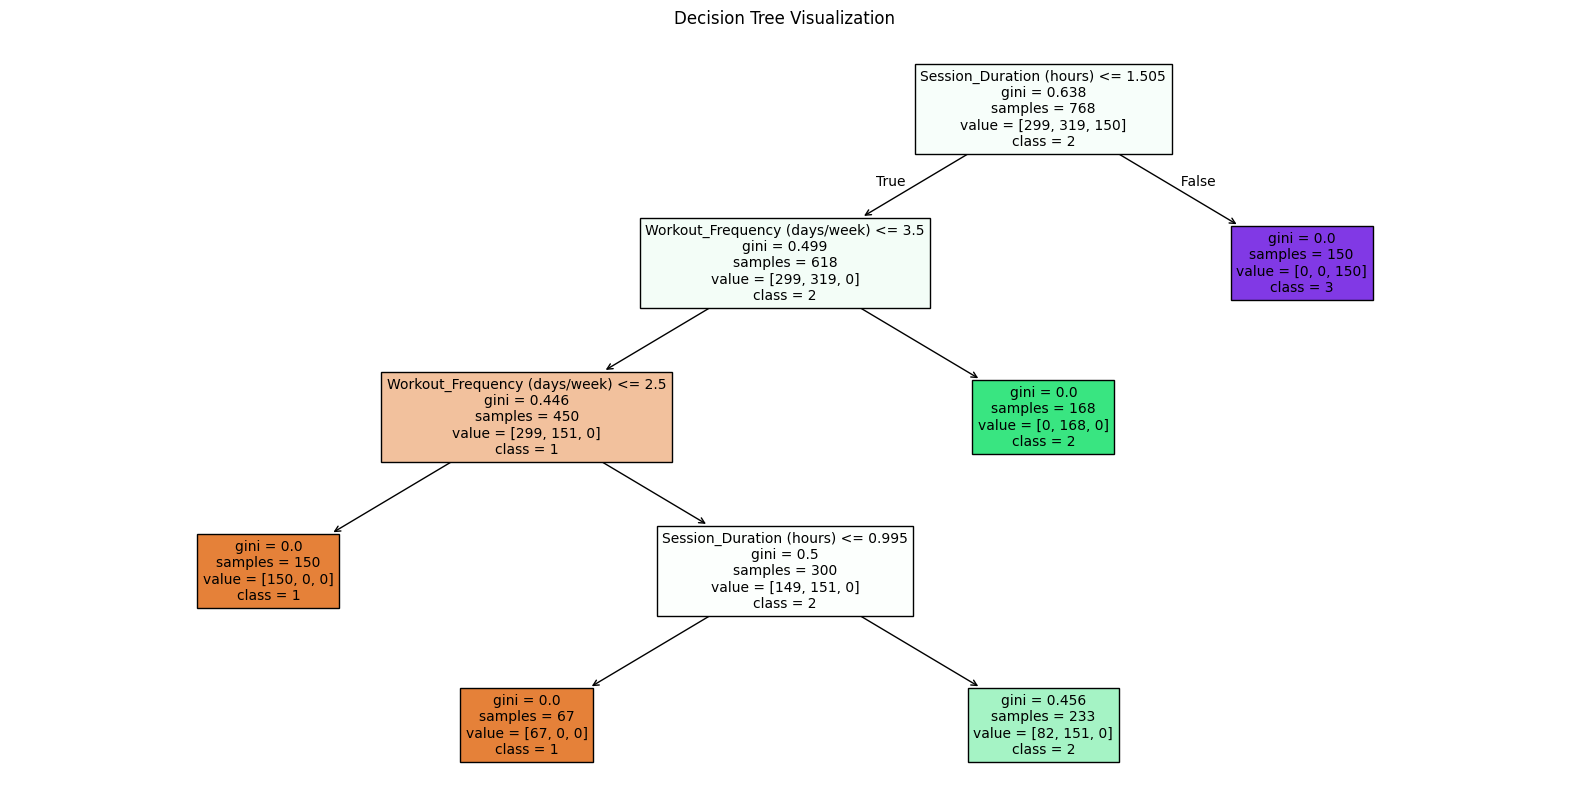

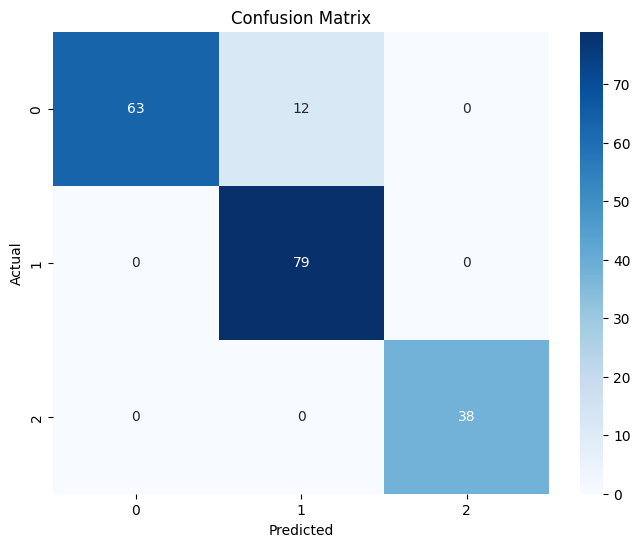


Classification Report:
              precision    recall  f1-score   support

           1       1.00      0.84      0.91        75
           2       0.87      1.00      0.93        79
           3       1.00      1.00      1.00        38

    accuracy                           0.94       192
   macro avg       0.96      0.95      0.95       192
weighted avg       0.95      0.94      0.94       192

Accuracy: 0.94


In [ ]:
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

plt.figure(figsize=(20, 10))
plot_tree(
    model,
    feature_names=X.columns.tolist(),
    class_names=[str(c) for c in model.classes_],
    filled=True,
    fontsize=10
)
plt.title('Decision Tree Visualization')
plt.show()

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Implementasi Data Keseluruhan

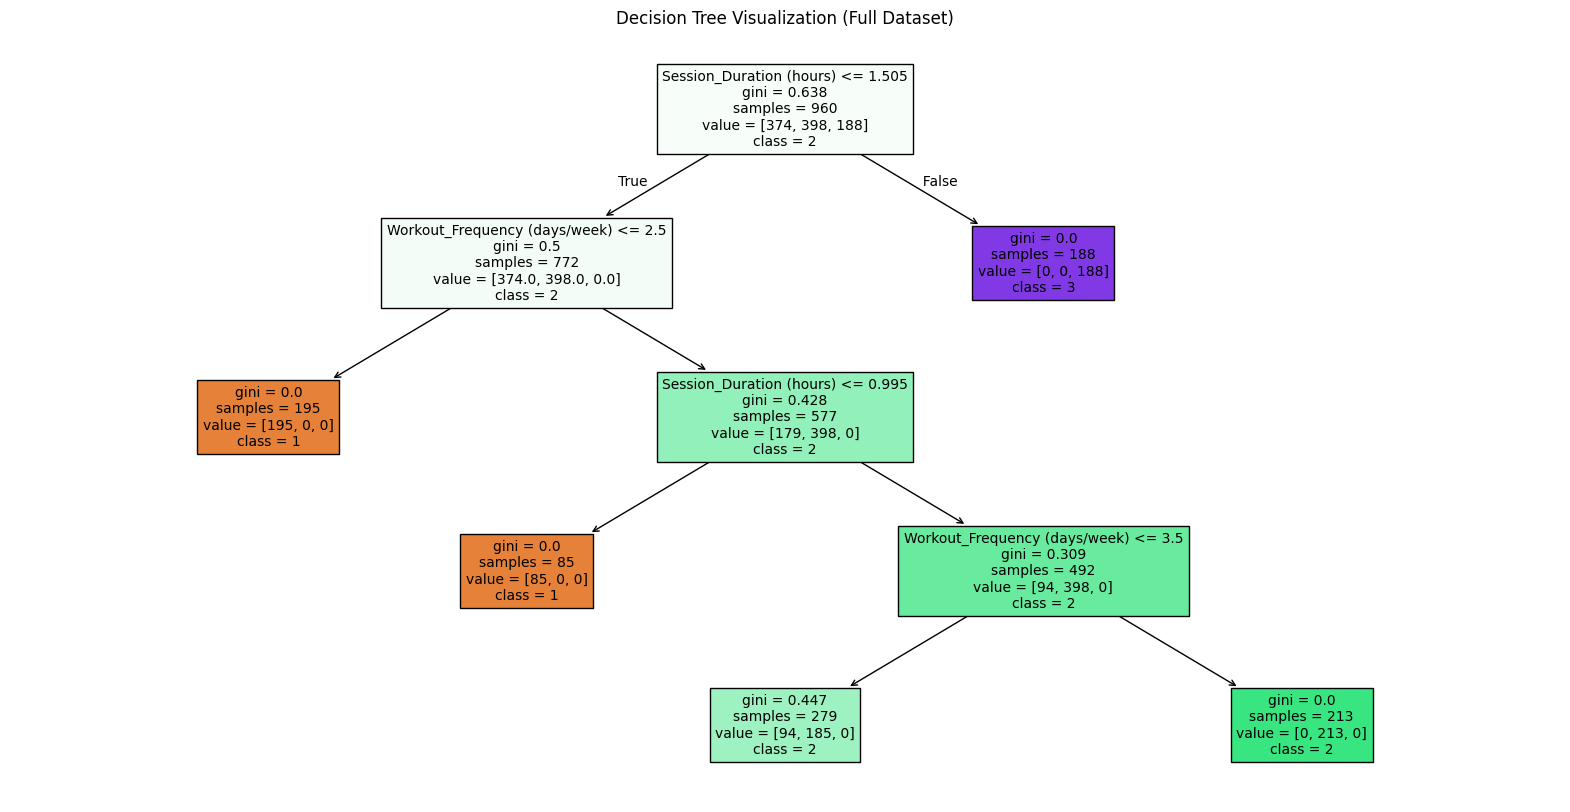

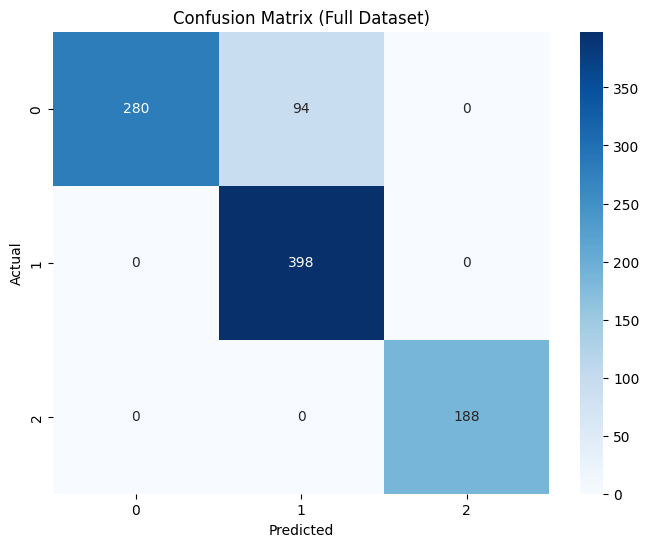


Classification Report (Full Dataset) :
              precision    recall  f1-score   support

           1       1.00      0.75      0.86       374
           2       0.81      1.00      0.89       398
           3       1.00      1.00      1.00       188

    accuracy                           0.90       960
   macro avg       0.94      0.92      0.92       960
weighted avg       0.92      0.90      0.90       960

Accuracy (Full Dataset) : 0.90
Model telah disimpan ke : decision_tree_model.pkl


In [ ]:
def preprocess_and_train_on_full_data(df_cleaned):
    X_all = df_cleaned.drop(columns=['Experience_Level'])
    y_all = df_cleaned['Experience_Level']

    model_full = DecisionTreeClassifier(max_depth=4, random_state=42)

    model_full.fit(X_all, y_all)

    y_pred_full = model_full.predict(X_all)

    accuracy_full = accuracy_score(y_all, y_pred_full)
    class_report_full = classification_report(y_all, y_pred_full)

    plt.figure(figsize=(20, 10))
    plot_tree(
        model_full,
        feature_names=X_all.columns.tolist(),
        class_names=[str(c) for c in model_full.classes_],
        filled=True,
        fontsize=10
    )
    plt.title('Decision Tree Visualization (Full Dataset)')
    plt.show()

    conf_matrix_full = confusion_matrix(y_all, y_pred_full)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix_full, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix (Full Dataset)')
    plt.show()

    print("\nClassification Report (Full Dataset) :")
    print(class_report_full)
    print(f"Accuracy (Full Dataset) : {accuracy_full:.2f}")

    return model_full

model_full = preprocess_and_train_on_full_data(df_cleaned)

import joblib
model_path = 'decision_tree_model.pkl'
joblib.dump(model_full, model_path)
print(f"Model telah disimpan ke : {model_path}")

Features Importance


Pentingnya Fitur :
                          Feature  Importance
7        Session_Duration (hours)    0.586236
12  Workout_Frequency (days/week)    0.413764
0                             Age    0.000000
1                          Gender    0.000000
2                     Weight (kg)    0.000000
3                      Height (m)    0.000000
4                         Max_BPM    0.000000
5                         Avg_BPM    0.000000
6                     Resting_BPM    0.000000
8                 Calories_Burned    0.000000
9                    Workout_Type    0.000000
10                 Fat_Percentage    0.000000
11          Water_Intake (liters)    0.000000
13                            BMI    0.000000


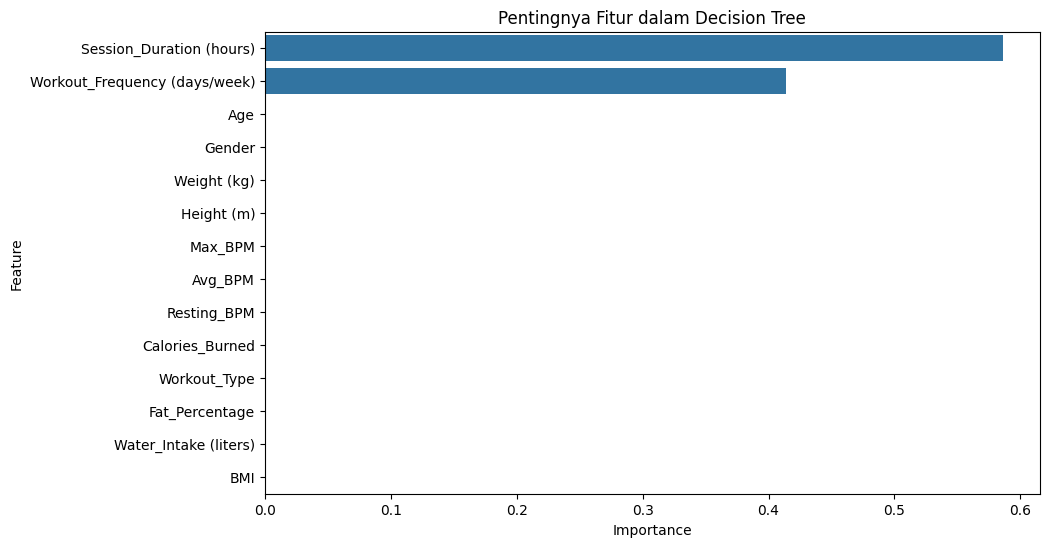

In [ ]:
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nPentingnya Fitur :")
print(feature_importances)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances)
plt.title('Pentingnya Fitur dalam Decision Tree')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

Analisis Korelasi

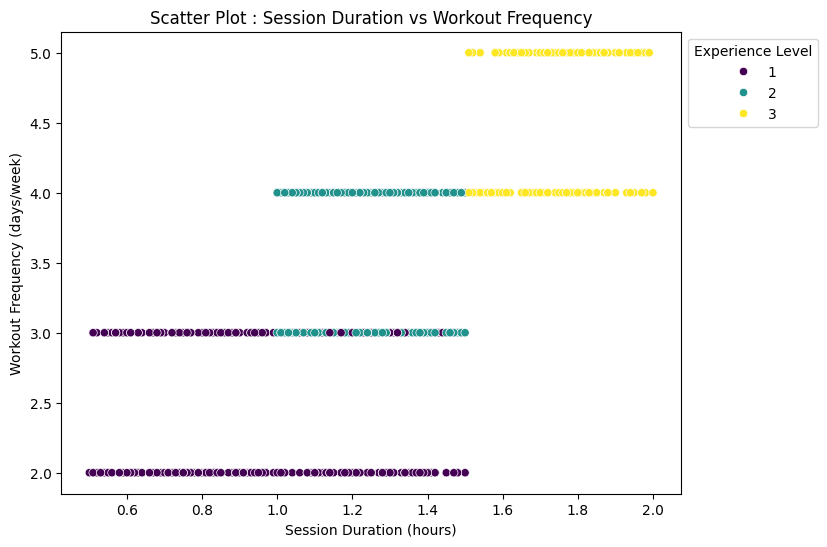

<ipython-input-238-32d6f988b43f>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


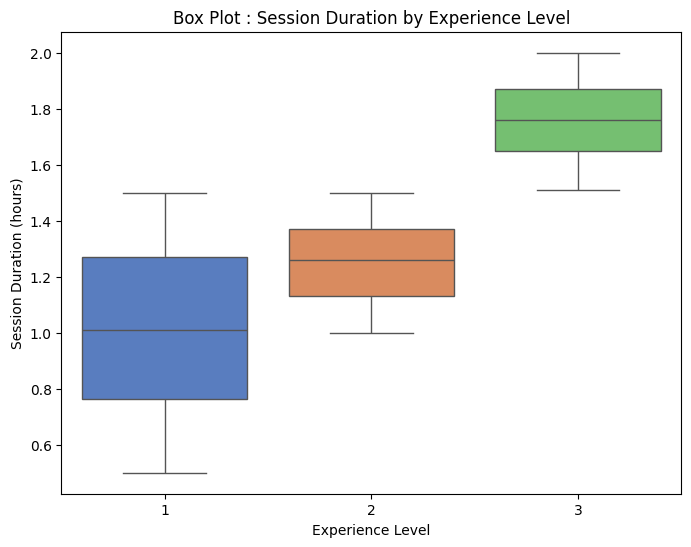

<ipython-input-238-32d6f988b43f>:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


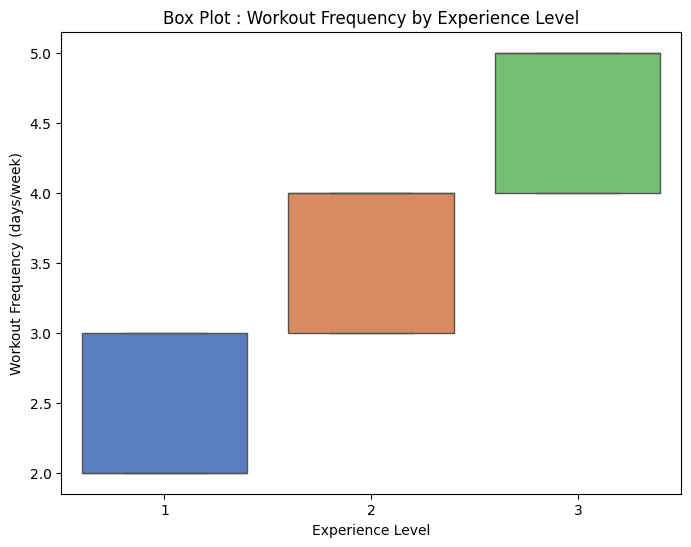

In [ ]:
columns_of_interest = ['Session_Duration (hours)', 'Workout_Frequency (days/week)', 'Experience_Level']
df_subset = df[columns_of_interest]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='Session_Duration (hours)',
    y='Workout_Frequency (days/week)',
    hue='Experience_Level',
    data=df_subset,
    palette='viridis'
)
plt.title('Scatter Plot : Session Duration vs Workout Frequency')
plt.xlabel('Session Duration (hours)')
plt.ylabel('Workout Frequency (days/week)')
plt.legend(title='Experience Level', loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(
    x='Experience_Level',
    y='Session_Duration (hours)',
    data=df_subset,
    palette='muted'
)
plt.title('Box Plot : Session Duration by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Session Duration (hours)')
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(
    x='Experience_Level',
    y='Workout_Frequency (days/week)',
    data=df_subset,
    palette='muted'
)
plt.title('Box Plot : Workout Frequency by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Workout Frequency (days/week)')
plt.show()
